In [14]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
# import requests

# MAP_KEY = 'cbf821fc44c5cdb58ef790f8c1540286'
# URL = 'https://firms.modaps.eosdis.nasa.gov/mapserver/mapkey_status/?MAP_KEY=' + MAP_KEY

# try:
#     response = requests.get(URL)
#     data = response.json()
#     df = pd.Series(data)
#     display(df)
# except:
#   print ("There is an issue with the query. \nTry in your browser: %s" % URL)

In [11]:
def group_granules(input_dir: Path) -> list[Path]:
    for path in input_dir.rglob(pattern='*.csv'):
        file : Path = path.resolve()
    return file

In [29]:
FIRM_DATA_DIR = Path('../../../firms_modis_mcd14/DL_FIRE_M-C61_811179/')
grouped_mcd61 = group_granules(FIRM_DATA_DIR)

df = pd.read_csv(grouped_mcd61)

gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326"
)
gdf.head(3)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,geometry
0,-14.2922,-67.6215,309.7,1.5,1.2,2023-01-01,307,Terra,MODIS,78,61.03,289.8,14.4,N,0,POINT (-67.6215 -14.2922)
1,0.9042,-74.5017,306.3,1.0,1.0,2023-01-01,311,Terra,MODIS,62,61.03,288.2,6.3,N,0,POINT (-74.5017 0.9042)
2,0.8042,-74.3628,308.0,1.0,1.0,2023-01-01,311,Terra,MODIS,43,61.03,290.4,8.0,N,0,POINT (-74.3628 0.8042)


/Users/kris/miniconda3/envs/analytics/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/kris/miniconda3/envs/analytics/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/kris/miniconda3/envs/analytics/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


<function matplotlib.pyplot.show(close=None, block=None)>

/Users/kris/miniconda3/envs/analytics/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/kris/miniconda3/envs/analytics/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


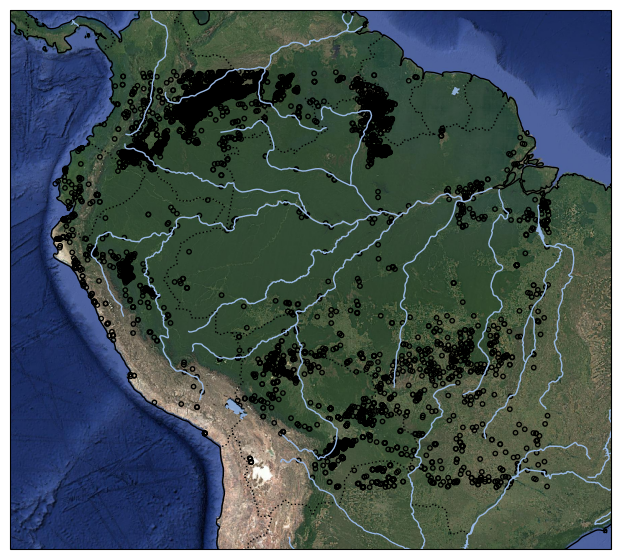

In [ ]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cartopy.io.img_tiles import GoogleTiles

tiler = GoogleTiles(style='satellite')
mercator = tiler.crs

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(
    [
        -84, -45, 
        -25, 10
    ], 
    crs=ccrs.PlateCarree()
)
ax.add_image(tiler, 6)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.9)
ax.add_feature(cfeature.RIVERS)

gdf = gdf[gdf.acq_time == time]
gdf.plot(ax=ax, marker='o', edgecolor='black', markersize=10, facecolor='None')

plt.show